# Explore models using Bertopic functions

The aim of this notebook is to take the raw model and explore topics using pre-defined bertopic functions

## Setting Libraries

In [1]:
import os
import sys

project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))

if project_root not in sys.path:
    sys.path.append(project_root)

In [2]:
import pipeline.src.python.config as cfg
from loguru import logger
import pandas as pd
pd.set_option('display.max_colwidth', None)
from bertopic import BERTopic
import pandas as pd
import torch
import numpy as np
import os
from sklearn.feature_extraction.text import CountVectorizer

/home/banfi/.uve/cuda/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Loading Model

In [22]:
MAGAZINE = 'science_news'
DATASET_TEXT_FEATURE = (
    "text"  # In the dataset file, the column name that contains the text data
)
cfg_dict = cfg.MAGAZINE_CONFIG[MAGAZINE]


In [23]:
model_path = cfg_dict['REFERENCE_MODEL']
#model_path = '/home/banfi/TETYS/pipeline/src/python/models/science_news/modelli_0_6B/model_0.309.safetensors'
print(f'Loading model: {model_path}')
model = BERTopic.load(model_path,#embedding_model=cfg.EMBEDDING_MODEL
                      )

2026-04-21 12:07:23,027 - BERTopic - WARNING: You are loading a BERTopic model without explicitly defining an embedding model. If you want to also load in an embedding model, make sure to use `BERTopic.load(my_model, embedding_model=my_embedding_model)`.


Loading model: /home/banfi/TETYS/pipeline/src/python/models/science_news/model_0.299_new4.safetensors


## Limit computational resources

In [25]:
os.environ["OMP_NUM_THREADS"] = "16"
os.environ["MKL_NUM_THREADS"] = "16"

logger.info(f"Set number of thread to: {os.environ["OMP_NUM_THREADS"]}")

torch.set_num_interop_threads(16)
torch.set_num_threads(16)

2026-04-10 09:07:35.714 | INFO     | __main__:<module>:4 - Set number of thread to: 16


RuntimeError: Error: cannot set number of interop threads after parallel work has started or set_num_interop_threads called

## Representation Update [Move to another notebook]

In [8]:
import re
import spacy
from spacy.lang.en.stop_words import STOP_WORDS

In [16]:
DATASET_PATH = cfg_dict['DATASET_PATH']
DATASET_TEXT_FEATURE = (
    "text"  # In the dataset file, the column name that contains the text data
)

DATASET_SPECIFIC_STOP_WORDS = cfg_dict["DOMAIN_SPECIFIC_STOP_WORDS"]

df = pd.read_parquet(DATASET_PATH)
documents = df[DATASET_TEXT_FEATURE].apply(str).to_list()

In [9]:
def preprocess_text(text):
    # Virus nomenclature: A(H7N9) → AH7N9
    text = re.sub(r'[\(\)\[\]\{\}]', ' ', text)
    text = re.sub(r"[.,]", " ", text)

    
    # Percentuali e numeri con simboli
    text = re.sub(r'\d+[\.,]?\d*\s*%', '', text)  # rimuovi percentuali
    text = re.sub(r'>\s*\d+', '', text)            # rimuovi ">80"
    text = re.sub(r'\d+\/\d+','',text)
    # Rimozione trattino iniziale e finale
    text = re.sub(r'(?<!\w)-|-(?!\w)', '', text)

    # Rimuovi riferimenti bibliografici tipo [1,2] o (Smith et al., 2020)
    text = re.sub(r'\[\d+(?:,\d+)*\]', '', text)
    text = re.sub(r'\([A-Z][a-z]+\s+et\s+al\.,?\s+\d{4}\)', '', text)

    return text


In [ ]:
data = np.load(cfg_dict['OUTPUT_PATH'],allow_pickle=True) 
#data = np.load('/home/banfi/TETYS/pipeline/src/python/data/interim/embeddings/the_guardian/the_guardian_embeddings_summary_filtered.npz',allow_pickle=True)

texts = data['text'] 

DOCSEP = "__DOCSEP__"
documents = [ f"{preprocess_text(text)} {DOCSEP} "  for text in texts]

STOP_SET = set(STOP_WORDS) | set(cfg_dict["DOMAIN_SPECIFIC_STOP_WORDS"])
ALLOWED_POS = {"NOUN",'PROPN',"ADJ"}


HYPHEN_RE = re.compile(r"[A-Za-z][A-Za-z0-9]*-[A-Za-z0-9]+")
DIGIT_RE = re.compile(r"\d")

nlp = spacy.load("en_core_web_md", disable=["parser", "ner"])

hyphen_token_re = re.compile(r"[A-Za-z][A-Za-z0-9]*(?:-[A-Za-z0-9]+)+")

nlp.tokenizer.token_match = hyphen_token_re.match


In [11]:
def pos_tokenizer(text):

        # Split the text in documents because BERTopic use the vectorizer in C-TF-Idf procedure joining the 
        # entire cluster texts creating a huge string that crash the RAM

        # We add DOCSEP to distinguish where split the text maintaining the right POS. 

        # We need to process text parts in batch e joining usefull keyword afterwards

        cluster_docs = [ cluster_doc.strip() for cluster_doc in text.split(DOCSEP.lower()) if cluster_doc.strip() ]

        #logger.info(f"Number of splitted docs: {len(cluster_docs)} docs")

        if not cluster_docs:
            return []
        
        results = []

        for doc in nlp.pipe(cluster_docs,batch_size=256):
            valid_tokens = []        

            for token in doc:
                
                # Avoid to add doc separator
                if "__docsep__" in token.text.lower():
                    print("Error doc sep found")
                    continue

                #if HYPHEN_RE.match(token.text) and DIGIT_RE.search(token.text):
                #    valid_tokens.append((token.i, token.text.lower()))
                #    continue

                if (
                    token.pos_ in ALLOWED_POS
                    and not token.is_punct
                    and not token.is_stop
                    and len(token.lemma_) > 2
                    and token.lemma_.lower() not in STOP_SET
                    and not token.is_digit
                ):
                    valid_tokens.append((token.i,token.lemma_.lower()))
            
            idxs =  [ token[0] for token in valid_tokens ]
            tokens = [ token[1] for token in valid_tokens ]   

            results.extend(tokens)
                
            # Bigrams only for the same document that have distance less than 2 words
            for i in range(len(tokens)-1):
                if idxs[i+1] - idxs[i] <= 2:
                    results.append(f"{tokens[i]}_{tokens[i+1]}")

        return results

vectorizer_model = CountVectorizer(
        tokenizer=pos_tokenizer,
        stop_words=None,  
        token_pattern=None,  
        ngram_range=(1, 1),
        min_df=3  
)

In [ ]:
vectorizer_model = CountVectorizer(
        stop_words=list(STOP_WORDS)+DATASET_SPECIFIC_STOP_WORDS,
        token_pattern="(?u)\\b[\\w-]+\\b",
        ngram_range=(1, 2)
    )



In [20]:
# ricalcola rappresentazione (c-TF-IDF) senza rifare clustering
model.update_topics(documents, vectorizer_model=vectorizer_model)

## Model Exploration

### Topic exploration

In [24]:
model.visualize_topics().show()

### Heatmap topic

In [27]:
model.visualize_heatmap().show()

### Model Bar chart

In [28]:

model.visualize_barchart().show()


### Model term rank

In [29]:
model.visualize_term_rank().show()


### Model Hierarchical clustering

In [30]:
model.visualize_hierarchy().show()


In [ ]:
model.custom_labels_[]

'-1_vaccine_pandemic_disease_immune_response'

### Word cloud 

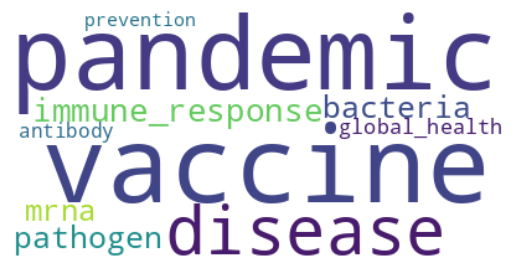

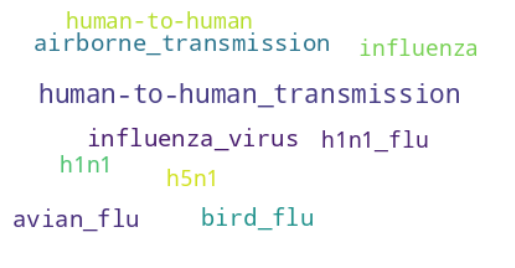

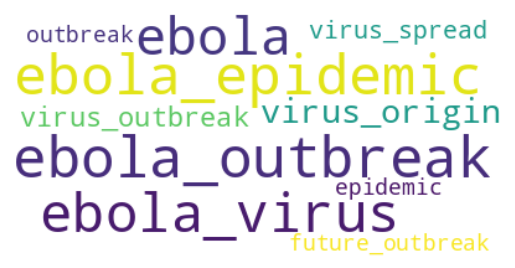

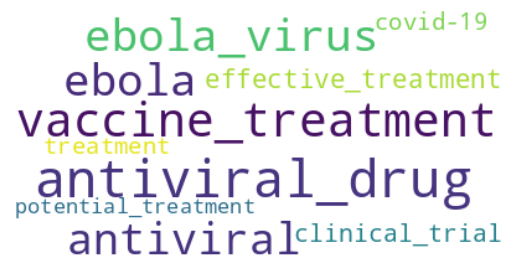

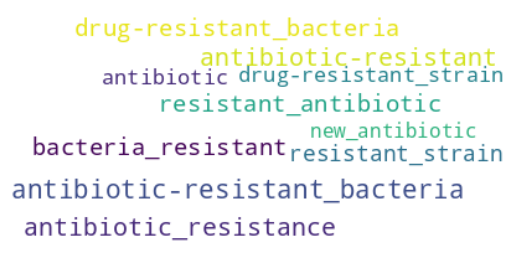

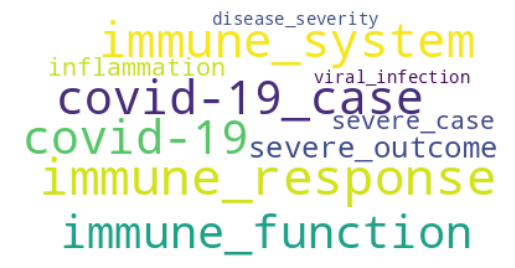

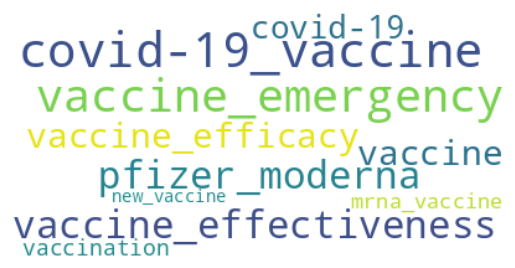

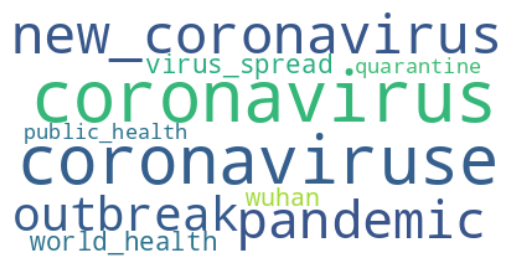

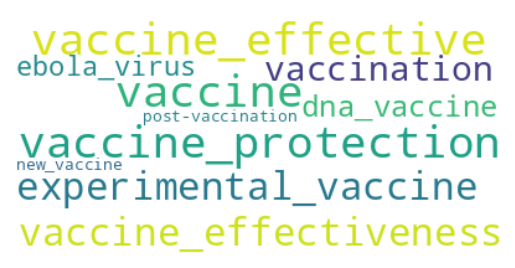

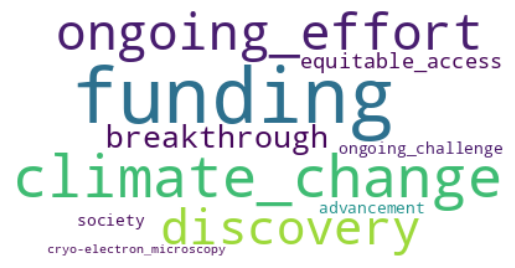

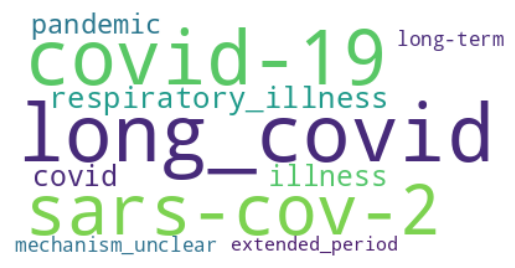

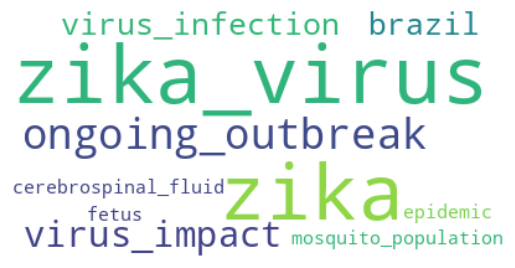

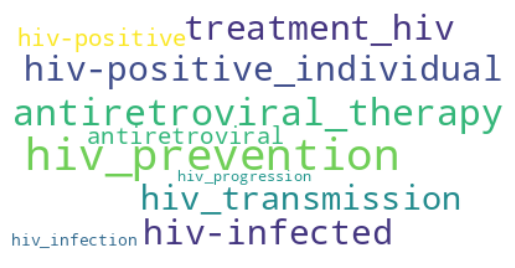

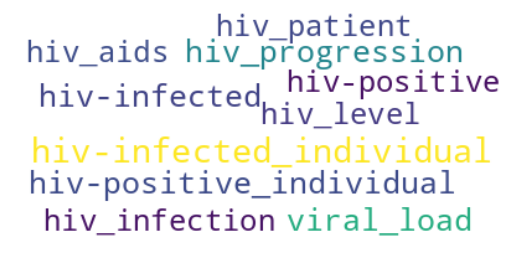

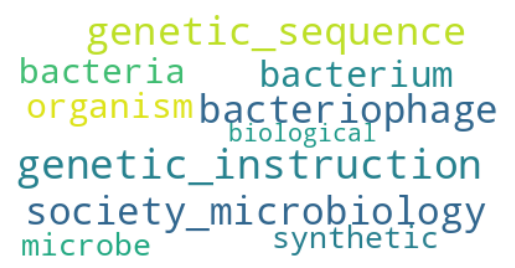

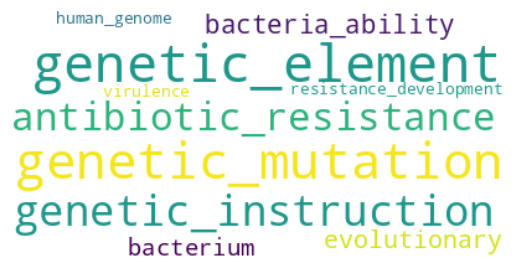

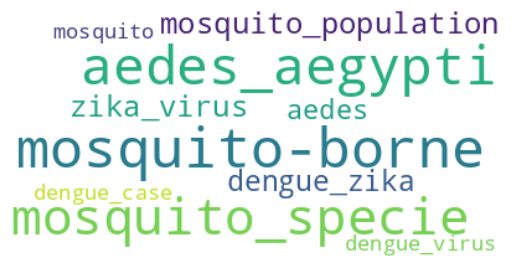

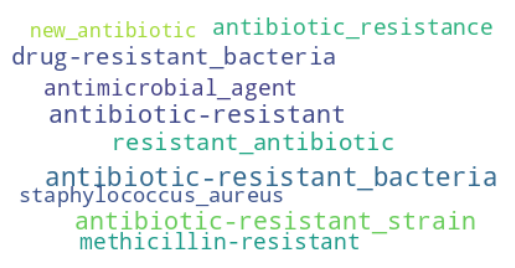

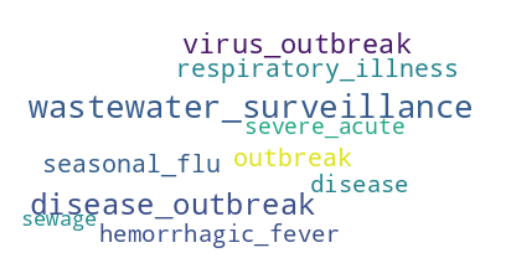

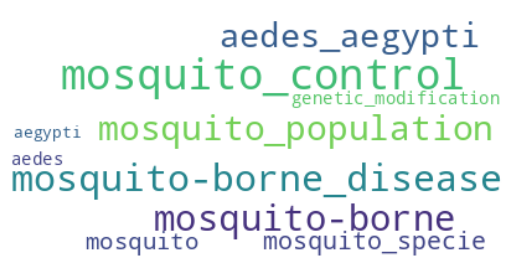

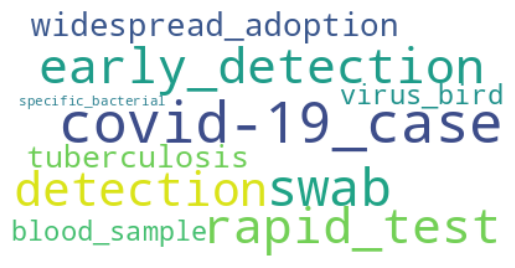

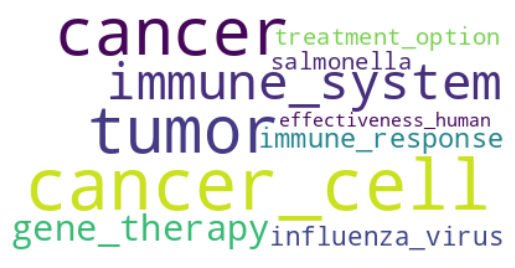

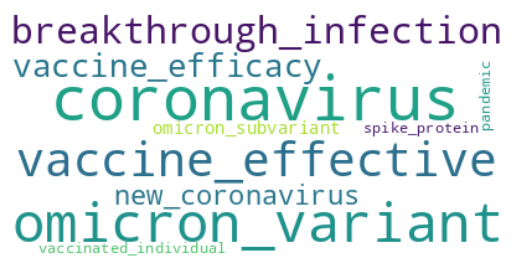

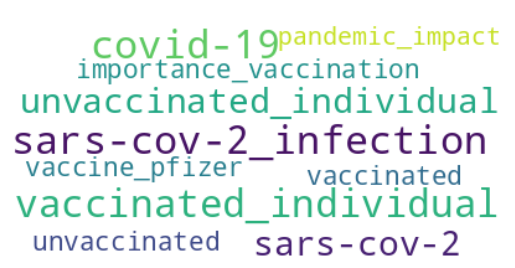

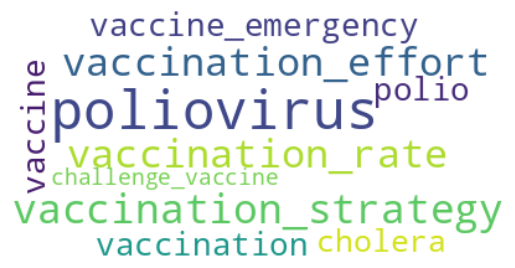

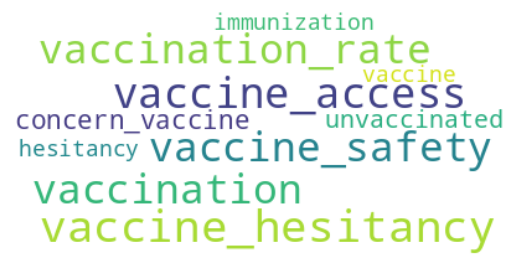

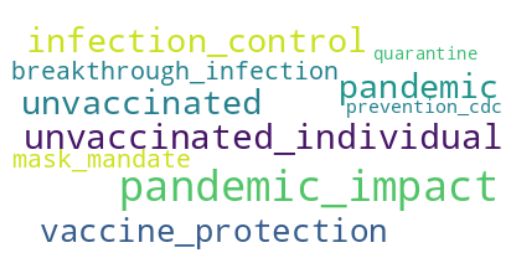

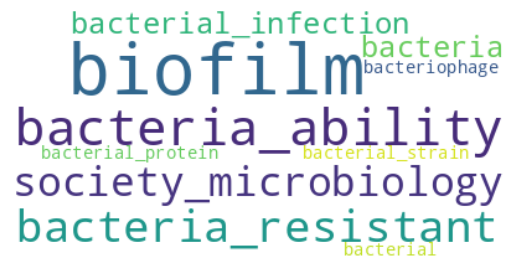

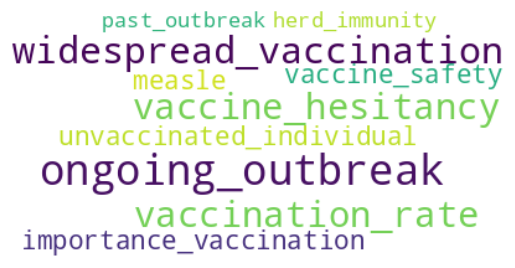

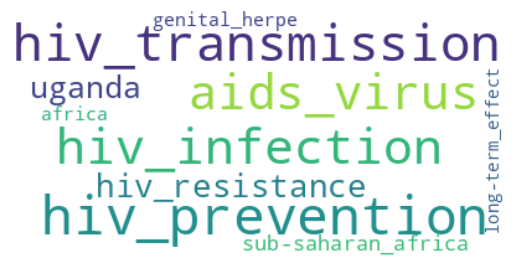

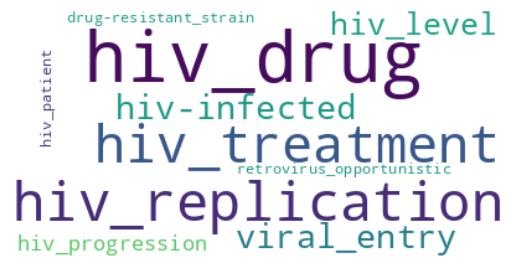

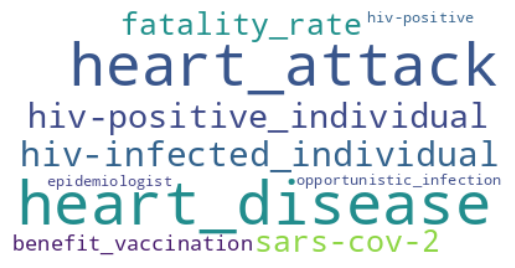

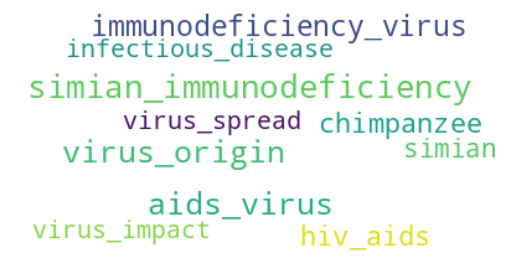

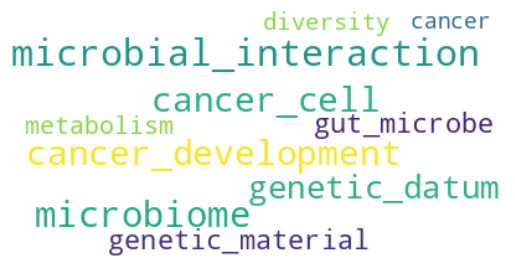

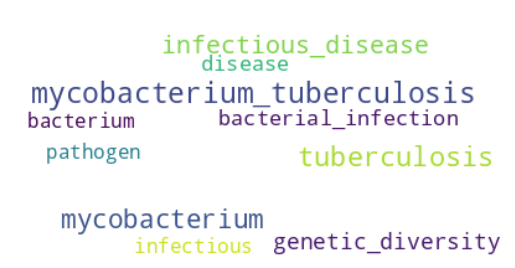

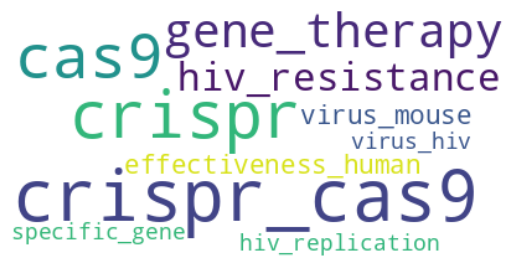

<Figure size 640x480 with 0 Axes>

In [25]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import time
def create_wordcloud(model, topic):
    text = {word: value for word, value in model.get_topic(topic)}
    wc = WordCloud(background_color="white", max_words=1000)
    wc.generate_from_frequencies(text)
    topic_label = model.custom_labels_[topic+1]
    plt.imshow(wc, interpolation="bilinear")
    #plt.savefig(f'./word_cloud/{MAGAZINE}/{MAGAZINE}_word_cloud_{topic}_{topic_label.replace("/","_")}.png')
    plt.axis("off")
    plt.show()

# Show wordcloud
topics = model.get_topics().keys()

#topics = [34,
#31,
#28,
#11,
#30,
#12,
#]


for i in topics :
    create_wordcloud(model, topic=i)
    plt.clf()

### View documents and topics

Loading data

In [ ]:
import numpy as np
DATASET_PATH = cfg_dict['DATASET_PATH']
#df = pd.read_parquet(DATASET_PATH)
df = pd.read_parquet('/home/banfi/TETYS/science_news_pipeline_data_class.parquet')
data = np.load(cfg_dict['OUTPUT_PATH'],allow_pickle=True)

ids = data['id']
texts = data['text']
embeddings = data['embedding']

IsADirectoryError: [Errno 21] Is a directory: '/home/banfi/TETYS/pipeline/src/python/models/science_news/model_0.299_new4.safetensors'

In [31]:
model.visualize_documents(texts, embeddings=embeddings)

NameError: name 'texts' is not defined